In [1]:
import pandas as pd


In [2]:
#Loading data
employee_data=pd.read_csv("employee_turnover.csv")

In [3]:
employee_data.head()

,Job_Satisfaction,Performance_Rating,Years_At_Company,Work_Life_Balance,Distance_From_Home,Monthly_Income,Education_Level,Age,Num_Companies_Worked,Employee_Role,Annual_Bonus,Training_Hours,Department,Annual_Bonus_Squared,Annual_Bonus_Training_Hours_Interaction,Employee_Turnover
0,0.562326,0.141129,0.123989,0.347583,0.330353,0.328853,0.600933,0.315990,0.768736,0.090671,0.324786,0.669193,0.602932,0.105486,0.217344,0
1,0.017041,0.559047,0.511203,0.793908,0.423550,0.553450,0.742009,0.897146,0.380035,0.601633,0.694611,0.043271,0.800761,0.482484,0.030056,0
2,0.774699,0.604371,0.798174,0.260500,0.804034,0.131800,0.775178,0.830947,0.218726,0.972936,0.153476,0.701336,0.705275,0.023555,0.107638,1
3,0.628174,0.385249,0.230104,0.516809,0.272248,0.589249,0.482409,0.090507,0.402746,0.132842,0.305973,0.549688,0.600531,0.093620,0.168190,0
4,0.799183,0.199967,0.839029,0.247927,0.341934,0.076818,0.055356,0.680860,0.923341,0.493017,0.844094,0.793751,0.664679,0.712494,0.670000,0


In [4]:
#Problem Definintion and IdentificationFeatures
X=employee_data.drop("Employee_Turnover",axis=1)
y=employee_data["Employee_Turnover"]

In [5]:
#Data Preparation and splitting

employee_data.isnull().sum() #this data is free from null values

#Training and splitting:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
#Building Baseline Model(Logistic Regression)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,precision_score

#Training Model (baseline)
model=LogisticRegression()
model.fit(X_train,y_train)

#Predicting
y_pred=model.predict(X_test)

#Evaluating model
accuracy=accuracy_score(y_test,y_pred)
precision=precision_score(y_test,y_pred)

print("Accuracy of the Model:",accuracy,"%")
print("Precision of the Model:",precision,"%")

Accuracy of the Model: 0.8592592592592593 %
Precision of the Model: 0.8717948717948718 %


In [20]:
#Regularization:
#1. Lasso Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score

l1_model = LogisticRegression(
    solver='saga',
    l1_ratio=1.0,   # L1
    max_iter=1000
)

l1_model.fit(X_train, y_train)
y_pred_l1 = l1_model.predict(X_test)

print("L1 Accuracy:", accuracy_score(y_test, y_pred_l1),"%")
print("L1 Precision:", precision_score(y_test, y_pred_l1),"%")

#Ridge Regression(L2)
l2_model = LogisticRegression(
    solver='saga',
    l1_ratio=0.0,   # L2
    max_iter=1000
)

l2_model.fit(X_train, y_train)
y_pred_l2 = l2_model.predict(X_test)

print("L2 Accuracy:", accuracy_score(y_test, y_pred_l2))
print("L2 Precision:", precision_score(y_test, y_pred_l2))

L1 Accuracy: 0.8629629629629629 %
L1 Precision: 0.8793103448275862 %
L2 Accuracy: 0.8592592592592593
L2 Precision: 0.8717948717948718


In [7]:
#Training both Models (L1 and L2)
#L1 model
l1_model=LogisticRegression(
    solver="saga",
    l1_ratio=1.0,
    C=1.0,
    max_iter=1000
)
l1_model.fit(X_train,y_train)

#L2 Model 
l2_model=LogisticRegression(
    solver="saga",
    l1_ratio=0.0,
    C=1.0,
    max_iter=1000
)
l2_model.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [8]:
#Comparing the models from recomending best
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score

# Train baseline model (FIX ADDED)
model = LogisticRegression(max_iter=1000, solver='saga')
model.fit(X_train, y_train)

# Baseline predictions
y_pred_base = model.predict(X_test)

# L1 predictions
y_pred_l1 = l1_model.predict(X_test)

# L2 predictions
y_pred_l2 = l2_model.predict(X_test)

# Results
print("Baseline Model")
print("Accuracy:", accuracy_score(y_test, y_pred_base))
print("Precision:", precision_score(y_test, y_pred_base))

print("\nL1 Model")
print("Accuracy:", accuracy_score(y_test, y_pred_l1))
print("Precision:", precision_score(y_test, y_pred_l1))

print("\nL2 Model")
print("Accuracy:", accuracy_score(y_test, y_pred_l2))
print("Precision:", precision_score(y_test, y_pred_l2))

Baseline Model
Accuracy: 0.8592592592592593
Precision: 0.8717948717948718

L1 Model
Accuracy: 0.8629629629629629
Precision: 0.8793103448275862

L2 Model
Accuracy: 0.8592592592592593
Precision: 0.8717948717948718


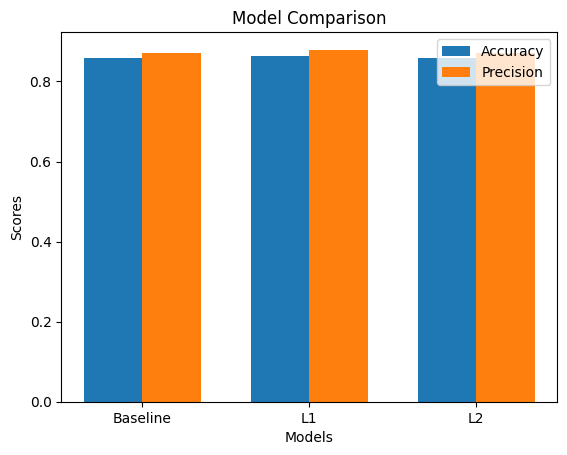

In [11]:
#Plotting the Grapgh of comparison
import numpy as np
import matplotlib.pyplot as plt

models = ['Baseline', 'L1', 'L2']

accuracy = [
    accuracy_score(y_test, y_pred_base),
    accuracy_score(y_test, y_pred_l1),
    accuracy_score(y_test, y_pred_l2)
]

precision = [
    precision_score(y_test, y_pred_base),
    precision_score(y_test, y_pred_l1),
    precision_score(y_test, y_pred_l2)
]

x = np.arange(len(models))
width = 0.35

plt.figure()
plt.bar(x - width/2, accuracy, width, label='Accuracy')
plt.bar(x + width/2, precision, width, label='Precision')

plt.xticks(x, models)
plt.xlabel("Models")
plt.ylabel("Scores")
plt.title("Model Comparison")
plt.legend()
plt.savefig("model_comparison.png")
plt.show()